# Diagnosing C_ell^gg Theory vs Simulation Discrepancy

## Observed problem
The ratio `C_ell^{gg,meas} / C_ell^{gg,theory}` shows:
- **ell [100, 300]: 1.52** (50% excess — 2-halo / large-scale regime)
- **ell [300, 700]: 1.03** (OK)
- **ell [700, 1200]: 0.75** (25% deficit — 1-halo / small-scale regime)

## Seven candidate root causes investigated here

| # | Issue | Impact | Section |
|---|-------|--------|---------|
| 1 | **n(z) shape mismatch** — analytic vs realized mock n(z) | Alters Limber integral weighting → scale-dependent bias | §1 |
| 2 | **HOD Ncen/Nsat mismatch** — interpolation artifacts in Mthresh or logNcen_interp | Wrong galaxy counts per mass bin | §2 |
| 3 | **Mass range truncation** — theory M_min=10^14 matches catalog but nM/resolution may be insufficient | Biased HMF integral, wrong nbar normalization | §3 |
| 4 | **Baryon suppression factor applied to P_gg** — `Pmm_sup = halofit / P_NFW` multiplied onto P_gg | Physically incorrect for galaxy clustering | §4 |
| 5 | **Effective galaxy bias** — sim vs theory large-scale bias | Wrong 2-halo amplitude | §5 |
| 6 | **Satellite radial profile / 1-halo term** — profile shape in sim vs Fourier-space uk_clm | Wrong small-scale power | §6 |
| 7 | **Shot noise & pixel window** — deconvolution correctness | Constant offset in C_ell | §7 |

In [ ]:
# ============================================================
# Setup: imports, config, pipeline objects, simulation data
# ============================================================
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

# increase default label size for better readability
plt.rcParams.update({'font.size': 16})
# increase legend font size
plt.rcParams.update({'legend.fontsize': 14})

import healpy as hp
import pickle as pk
import jax
import jax.numpy as jnp
import jax.scipy.integrate as jsi

plt.rcParams['text.usetex'] = True

from paste_backlight_utils import (
    get_project_paths, build_config, load_halo_catalog,
    generate_maps, make_galaxy_map, compute_ngal_vs_z,
    check_nz_nbar_consistency, nbar_to_nz_lens,
    measure_hod_from_catalog,
    compute_shot_noise_Cl, compute_Cl_ratio_in_bands,
    compare_sim_vs_theory_hmf,
    compute_Cl_gg_1h_2h, compute_hod_shot_noise_Cl,
    compute_dV_dz_per_sr,
)

paths = get_project_paths()

from get_sim_maps import setup_sim_map
from scipy import interpolate
from scipy.interpolate import interp1d
from jax_cosmo.background import radial_comoving_distance

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
# Build config and initialize the theory pipeline
(sim_params_dict, halo_params_dict, analysis_dict,
 other_params_dict, cosmo_jax, zarray_lens, nz_lens, gal_zrange) = build_config(
    paths["params"], paths["data"])

gal_zmin, gal_zmax = gal_zrange
print(f"Galaxy z-range: [{gal_zmin}, {gal_zmax}]")
print(f"Halo mass range: [{halo_params_dict['lg10_Mmin']}, {halo_params_dict['lg10_Mmax']}], nM={halo_params_dict['nM']}")
print(f"z grid: [{halo_params_dict['zmin']}, {halo_params_dict['zmax']}], nz={halo_params_dict['nz']}")

from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl

base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)

[nz consistency] max fractional mismatch = 0.0000e+00, mean = 0.0000e+00  (rtol=0.05)
Galaxy z-range: [0.005, 0.3]
Halo mass range: [14.0, 15.75], nM=32
z grid: [0.005, 0.8], nz=31


In [2]:
# Load halo catalog and saved simulation data
nside = 512
sdir = f"{paths['data']}/backlight"
save_map_fname = f"{sdir}/allmaps_sim_B12_nside{nside}_split0of1_paste_testlowmass.pkl"

ra_all, dec_all, z_all, M200c_all, vlos_all = load_halo_catalog(
    f"{sdir}/halo_catalog_Mlim_1e14_zlim_0.4.h5")

saved_data = pk.load(open(save_map_fname, "rb"))
mock_gals = saved_data["mock_gals_all"][0]

# Build galaxy map and measure Cl_gg
map_gal = make_galaxy_map(mock_gals, nside, zmin=gal_zmin, zmax=gal_zmax)
delta_gal = map_gal / np.mean(map_gal)
Cl_gg_raw = hp.anafast(delta_gal)
ell = np.arange(len(Cl_gg_raw))
pixwin2 = hp.pixwin(nside)[:len(Cl_gg_raw)] ** 2
Cl_gg_deconv = Cl_gg_raw / np.where(pixwin2 > 0, pixwin2, 1.0)

# Shot noise
Cl_shot, n_gal, nbar_sr = compute_shot_noise_Cl(mock_gals, nside, gal_zmin, gal_zmax)
Cl_gg_no_shot = Cl_gg_deconv - Cl_shot

# Theory
ell_th = np.array(Cls_test.ell_array)
Cl_th = np.array(Cls_test.Cl_gal_gal_tot_mat[:, 0, 0])

print(f"\nHalos: {len(M200c_all)}, Galaxies: {n_gal}")
print(f"log10(M200c) range: [{np.log10(M200c_all).min():.2f}, {np.log10(M200c_all).max():.2f}]")
print(f"z range: [{z_all.min():.3f}, {z_all.max():.3f}]")

[Shot noise] N_gal = 209490, nbar = 16670.7 /sr, Cl_shot = 5.9986e-05

Halos: 83372, Galaxies: 209490
log10(M200c) range: [14.00, 15.31]
z range: [0.010, 0.397]


## §1 — n(z) shape mismatch: analytic vs realized galaxy n(z)

The theory Cl_gg uses `Wg(z) = nz_lens(z)` interpolated onto a 128-point z_array_for_Cls grid.
The simulation populates galaxies with HOD draws at discrete halo redshifts.
If the realized n(z) shape differs from the analytic one, the Limber integral weights
different redshifts differently → **scale-dependent** bias in the ratio.

We compare:
1. The analytic `nz_lens` (from `build_config`)
2. The realized galaxy n(z) histogram
3. The `Wg_mat` kernel actually used in the Limber integral

Wg integral over z_for_Cls: 1.000000 (should be ~1.0)
Wg support: nonzero at 49 of 128 z-points
Wg max at z = 0.283


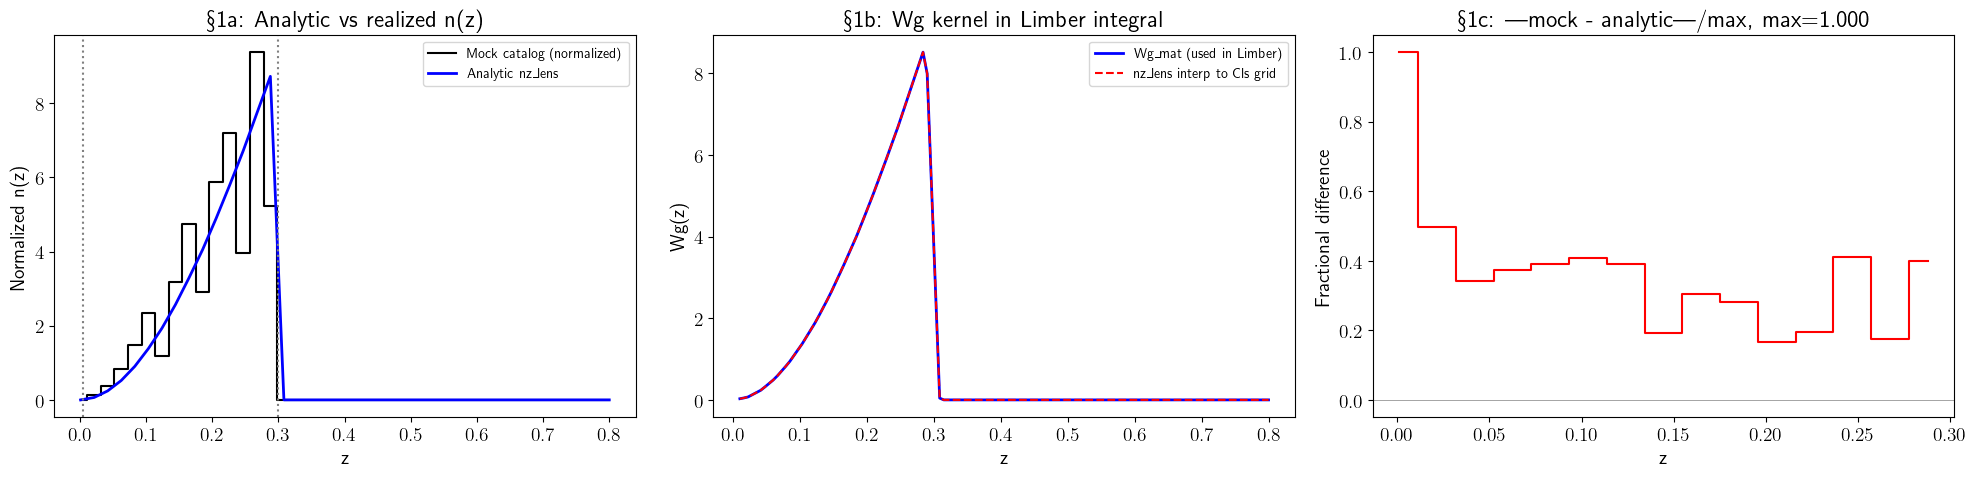

In [15]:
# §1: n(z) shape mismatch
gal_z_all = mock_gals[:, 2]

# (a) Analytic nz_lens on its native grid
nz_analytic = nz_lens[0]  # shape (len(zarray_lens),)

# (b) Realized galaxy n(z) histogram on the same grid
dz = zarray_lens[1] - zarray_lens[0]
bin_edges = np.concatenate([
    [zarray_lens[0] - dz/2],
    0.5*(zarray_lens[1:] + zarray_lens[:-1]),
    [zarray_lens[-1] + dz/2],
])
sel_z = (gal_z_all >= gal_zmin) & (gal_z_all <= gal_zmax)
counts, _ = np.histogram(gal_z_all[sel_z], bins=bin_edges)
nz_mock_raw = counts.astype(float)
nz_mock_norm = nz_mock_raw / np.trapz(nz_mock_raw, zarray_lens) if nz_mock_raw.sum() > 0 else nz_mock_raw

# (c) Wg_mat kernel actually used in Limber integral
z_for_Cls = np.array(Cls_test.z_array_for_Cls)
Wg_actual = np.array(Cls_test.Wg_mat[0])  # shape (nz_for_Cls,)

# Reconstruct what Wg should be from nz_analytic interpolated to z_for_Cls
nz_on_Cls_grid = np.interp(z_for_Cls, zarray_lens, nz_analytic, left=0, right=0)
nz_on_Cls_norm = nz_on_Cls_grid / np.trapz(nz_on_Cls_grid, z_for_Cls) if nz_on_Cls_grid.sum() > 0 else nz_on_Cls_grid

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: n(z) comparison
axes[0].step(zarray_lens, nz_mock_norm, where='mid', color='k', lw=1.5, label='Mock catalog (normalized)')
axes[0].plot(zarray_lens, nz_analytic, 'b-', lw=2, label='Analytic nz\\_lens')
axes[0].axvline(gal_zmin, ls=':', color='gray')
axes[0].axvline(gal_zmax, ls=':', color='gray')
axes[0].set(xlabel='z', ylabel='Normalized n(z)', title='§1a: Analytic vs realized n(z)')
axes[0].legend(fontsize=10)

# Panel 2: Wg kernel
axes[1].plot(z_for_Cls, Wg_actual, 'b-', lw=2, label='Wg\\_mat (used in Limber)')
axes[1].plot(z_for_Cls, nz_on_Cls_norm, 'r--', lw=1.5, label='nz\\_lens interp to Cls grid')
axes[1].set(xlabel='z', ylabel='Wg(z)', title='§1b: Wg kernel in Limber integral')
axes[1].legend(fontsize=10)

# Panel 3: fractional difference where nz > 0
mask_nz = (nz_analytic > 1e-10) | (nz_mock_norm > 1e-10)
if mask_nz.any():
    denom_nz = np.maximum(nz_analytic[mask_nz], nz_mock_norm[mask_nz])
    frac_nz = np.abs(nz_mock_norm[mask_nz] - nz_analytic[mask_nz]) / np.where(denom_nz > 0, denom_nz, 1.0)
    axes[2].step(zarray_lens[mask_nz], frac_nz, where='mid', color='r', lw=1.5)
    axes[2].set(xlabel='z', ylabel='Fractional difference', title=f'§1c: |mock - analytic|/max, max={frac_nz.max():.3f}')
    axes[2].axhline(0, ls='-', color='gray', lw=0.5)

plt.tight_layout()

# Wg normalization check
Wg_integral = np.trapz(Wg_actual, z_for_Cls)
print(f"Wg integral over z_for_Cls: {Wg_integral:.6f} (should be ~1.0)")
print(f"Wg support: nonzero at {(Wg_actual > 1e-6).sum()} of {len(Wg_actual)} z-points")
print(f"Wg max at z = {z_for_Cls[np.argmax(Wg_actual)]:.3f}")

## §2 — HOD Ncen/Nsat mismatch: theory tables vs simulation interpolation

The theory pipeline computes `Ncen_mat(z, M)` and `Nsat_mat(z, M)` on the (z_array, M_array) grid.
The simulation uses `interpax.Interpolator2D` in log space to interpolate these to each halo's exact (z, M).

Potential issues:
- Interpolation in log(Ncen + 1e-20) can be inaccurate where Ncen transitions from ~0 to ~1
- M_array only goes up to 10^15.75 — halos above this get extrapolated with `extrap=[-20, -20]`
- The Mthresh solver may hit boundaries if nbar is too high/low for the HMF at that z

  Mthresh / nbar DIAGNOSTIC
Mthresh solver boundaries: log10M = [9.0, 16.0]
Mthresh (log10): min=14.247, median=16.000, max=16.000

     z   log10Mth    nbar_tgt   nbar_real   frac_diff
----------------------------------------------------
 0.005     14.975   9.762e-06   9.722e-06      0.0041
 0.032     14.447   5.000e-05   4.993e-05      0.0013
 0.058     14.433   5.000e-05   4.989e-05      0.0021
 0.085     14.416   5.000e-05   4.992e-05      0.0016
 0.111     14.396   5.000e-05   4.996e-05      0.0007
 0.138     14.377   5.000e-05   4.990e-05      0.0020
 0.164     14.353   5.000e-05   4.996e-05      0.0009
 0.191     14.330   5.000e-05   4.992e-05      0.0016
 0.217     14.304   5.000e-05   4.994e-05      0.0013
 0.244     14.276   5.000e-05   4.993e-05      0.0015
 0.270     14.247   5.000e-05   4.994e-05      0.0011
 0.296     14.431   2.882e-05   2.875e-05      0.0023

Active z-bins: max frac diff = 4.0944e-03, mean = 1.7170e-03

  z=0.323, log10Mth=16.000 [HIGH]
  z=0.350, log10

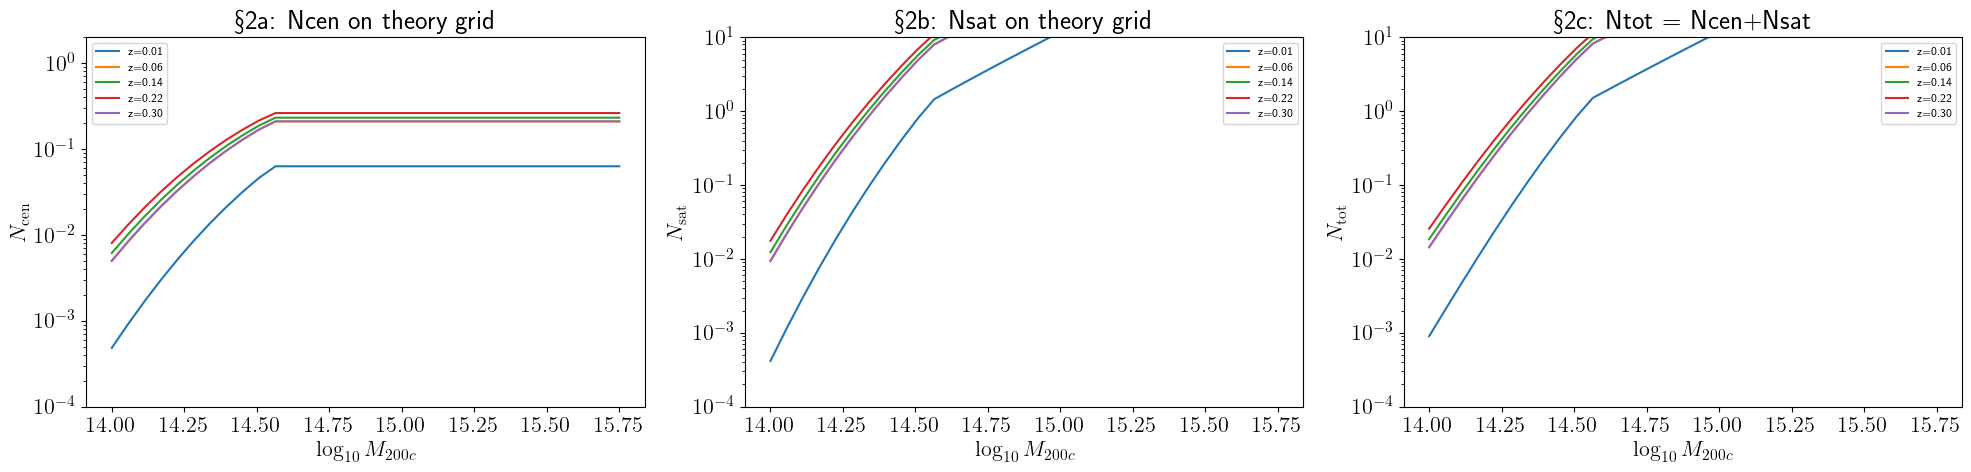

In [19]:
# §2: HOD occupancy — theory grid vs simulation interpolation
# Compare Ncen/Nsat from the theory grid against what the simulation interpolator gives

z_th = np.array(Cls_test.z_array)
M_th = np.array(Cls_test.M_array)
logM_th = np.log10(M_th)
Ncen_mat = np.array(Cls_test.Ncen_mat)  # (nz, nM)
Nsat_mat = np.array(Cls_test.Nsat_mat)  # (nz, nM)

# Mthresh diagnostics
Mthresh_arr = np.array(Cls_test.Mthresh_array)
log10_Mthresh = np.log10(Mthresh_arr)
MTHRESH_LOG10_LO, MTHRESH_LOG10_HI = 9.0, 16.0

print("=" * 65)
print("  Mthresh / nbar DIAGNOSTIC")
print("=" * 65)
print(f"Mthresh solver boundaries: log10M = [{MTHRESH_LOG10_LO}, {MTHRESH_LOG10_HI}]")
print(f"Mthresh (log10): min={log10_Mthresh.min():.3f}, median={np.median(log10_Mthresh):.3f}, max={log10_Mthresh.max():.3f}")

# nbar target vs realized
nbar_target = np.interp(z_th, analysis_dict["nbar_gal_comoving_zarray"],
                        analysis_dict["nbar_gal_comoving_val"])
nbar_realized = np.array(Cls_test.nbarz)

print(f"\n{'z':>6s}  {'log10Mth':>9s}  {'nbar_tgt':>10s}  {'nbar_real':>10s}  {'frac_diff':>10s}")
print("-" * 52)
active = nbar_target > 1e-15
frac_diffs = np.zeros(len(z_th))
for i in range(len(z_th)):
    nt, nr = nbar_target[i], nbar_realized[i]
    denom = max(abs(nt), abs(nr), 1e-30)
    fd = abs(nt - nr) / denom if denom > 1e-30 else 0.0
    frac_diffs[i] = fd
    if active[i]:
        print(f"{z_th[i]:6.3f}  {log10_Mthresh[i]:9.3f}  {nt:10.3e}  {nr:10.3e}  {fd:10.4f}")

if active.any():
    print(f"\nActive z-bins: max frac diff = {frac_diffs[active].max():.4e}, mean = {frac_diffs[active].mean():.4e}")

# Boundary check
MARGIN = 0.15
near_lo = log10_Mthresh < (MTHRESH_LOG10_LO + MARGIN)
near_hi = log10_Mthresh > (MTHRESH_LOG10_HI - MARGIN)
boundary = near_lo | near_hi
if boundary.any():
    print(f"\nWARNING: {boundary.sum()} z-bin(s) near solver boundary (margin={MARGIN} dex):")
    for i in np.where(boundary)[0]:
        print(f"  z={z_th[i]:.3f}, log10Mth={log10_Mthresh[i]:.3f} [{'LOW' if near_lo[i] else 'HIGH'}]")
else:
    print(f"\nBoundary check OK (margin={MARGIN} dex)")

# Plot Ncen and Nsat on the theory grid
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Select a few z slices inside the galaxy window
z_inside = np.where(active)[0]
z_sel = z_inside[np.linspace(0, len(z_inside)-1, min(5, len(z_inside))).astype(int)]

for jz in z_sel:
    axes[0].plot(logM_th, Ncen_mat[jz], label=f'z={z_th[jz]:.2f}')
    axes[1].plot(logM_th, Nsat_mat[jz], label=f'z={z_th[jz]:.2f}')
    axes[2].plot(logM_th, Ncen_mat[jz] + Nsat_mat[jz], label=f'z={z_th[jz]:.2f}')

axes[0].set(xlabel=r'$\log_{10} M_{200c}$', ylabel=r'$N_{\rm cen}$', title='§2a: Ncen on theory grid', yscale='log', ylim=(1e-4, 2))
axes[0].legend(fontsize=12)
axes[1].set(xlabel=r'$\log_{10} M_{200c}$', ylabel=r'$N_{\rm sat}$', title='§2b: Nsat on theory grid', yscale='log', ylim=(1e-4, 10))
axes[1].legend(fontsize=12)
axes[2].set(xlabel=r'$\log_{10} M_{200c}$', ylabel=r'$N_{\rm tot}$', title='§2c: Ntot = Ncen+Nsat', yscale='log', ylim=(1e-4, 10))
axes[2].legend(fontsize=12)
plt.tight_layout()

--- HOD Consistency Diagnostics ---
  Ncen: max frac mismatch = 10838.313, mean = 386.875 (over 40 populated bins)
  Nsat: max frac mismatch = 125592.384, mean = 3913.367 (over 39 populated bins)
-----------------------------------
Ncen mismatch: max=10838.313, mean=386.875
Nsat mismatch: max=125592.384, mean=3913.367


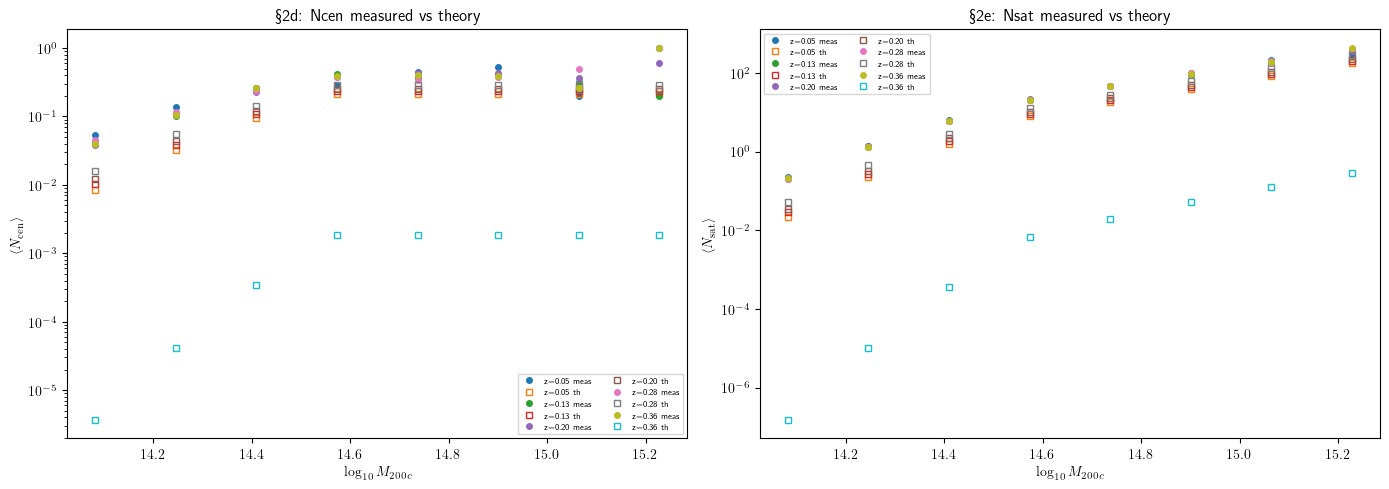

In [5]:
# §2 continued: Compare theory-grid Ncen/Nsat vs simulation catalog measurements
hod_diag = measure_hod_from_catalog(mock_gals, M200c_all, z_all, Cls_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for iz in range(len(hod_diag['z_cen'])):
    lbl = f"z={hod_diag['z_cen'][iz]:.2f}"
    valid = np.isfinite(hod_diag['Ncen_meas'][iz])
    if valid.any():
        axes[0].plot(hod_diag['logM_cen'][valid], hod_diag['Ncen_meas'][iz, valid],
                     'o', ms=4, label=lbl + ' meas')
        axes[0].plot(hod_diag['logM_cen'][valid], hod_diag['Ncen_th'][iz, valid],
                     's', ms=4, mfc='none', label=lbl + ' th')
    valid_s = np.isfinite(hod_diag['Nsat_meas'][iz])
    if valid_s.any():
        axes[1].plot(hod_diag['logM_cen'][valid_s], hod_diag['Nsat_meas'][iz, valid_s],
                     'o', ms=4, label=lbl + ' meas')
        axes[1].plot(hod_diag['logM_cen'][valid_s], hod_diag['Nsat_th'][iz, valid_s],
                     's', ms=4, mfc='none', label=lbl + ' th')

axes[0].set(xlabel=r'$\log_{10} M_{200c}$', ylabel=r'$\langle N_{\rm cen} \rangle$',
            title='§2d: Ncen measured vs theory', yscale='log')
axes[0].legend(fontsize=6, ncol=2)
axes[1].set(xlabel=r'$\log_{10} M_{200c}$', ylabel=r'$\langle N_{\rm sat} \rangle$',
            title='§2e: Nsat measured vs theory', yscale='log')
axes[1].legend(fontsize=6, ncol=2)
plt.tight_layout()

# Quantify the mismatch
valid_cen = np.isfinite(hod_diag['frac_mismatch_Ncen'])
valid_sat = np.isfinite(hod_diag['frac_mismatch_Nsat'])
if valid_cen.any():
    print(f"Ncen mismatch: max={np.nanmax(hod_diag['frac_mismatch_Ncen']):.3f}, mean={np.nanmean(hod_diag['frac_mismatch_Ncen']):.3f}")
if valid_sat.any():
    print(f"Nsat mismatch: max={np.nanmax(hod_diag['frac_mismatch_Nsat']):.3f}, mean={np.nanmean(hod_diag['frac_mismatch_Nsat']):.3f}")

## §3 — Mass range truncation and HMF resolution

Theory M_array runs from `lg10_Mmin=14.0` to `lg10_Mmax=15.75` with nM=32.
This means:
- Halos below 10^14 are excluded from the HMF integral → nbar, bias, 1h/2h power all only integrate above this floor
- The halo catalog is also cut at M > 10^14, so this should be self-consistent **but** the Mthresh solver uses `logspace(9, 14)` which extends far below M_array

Key question: does the mass resolution (32 points between 10^14 and 10^15.75) adequately resolve the HMF?

[HMF comparison — ABSOLUTE] max frac mismatch = 1.000, mean = 0.443 (over 53 bins with >5 halos)
  Total sim = 76023, total theory(abs) = 31329, ratio = 2.4266
[HMF comparison — renorm]   max frac mismatch = 1.000, mean = 0.376

Total sim halos: 76023
Total theory halos (absolute): 31329
Ratio sim/theory: 2.4266

M_array: 32 points from 10^14.00 to 10^15.75
dlnM spacing: 0.1300 (dex: 0.0565)


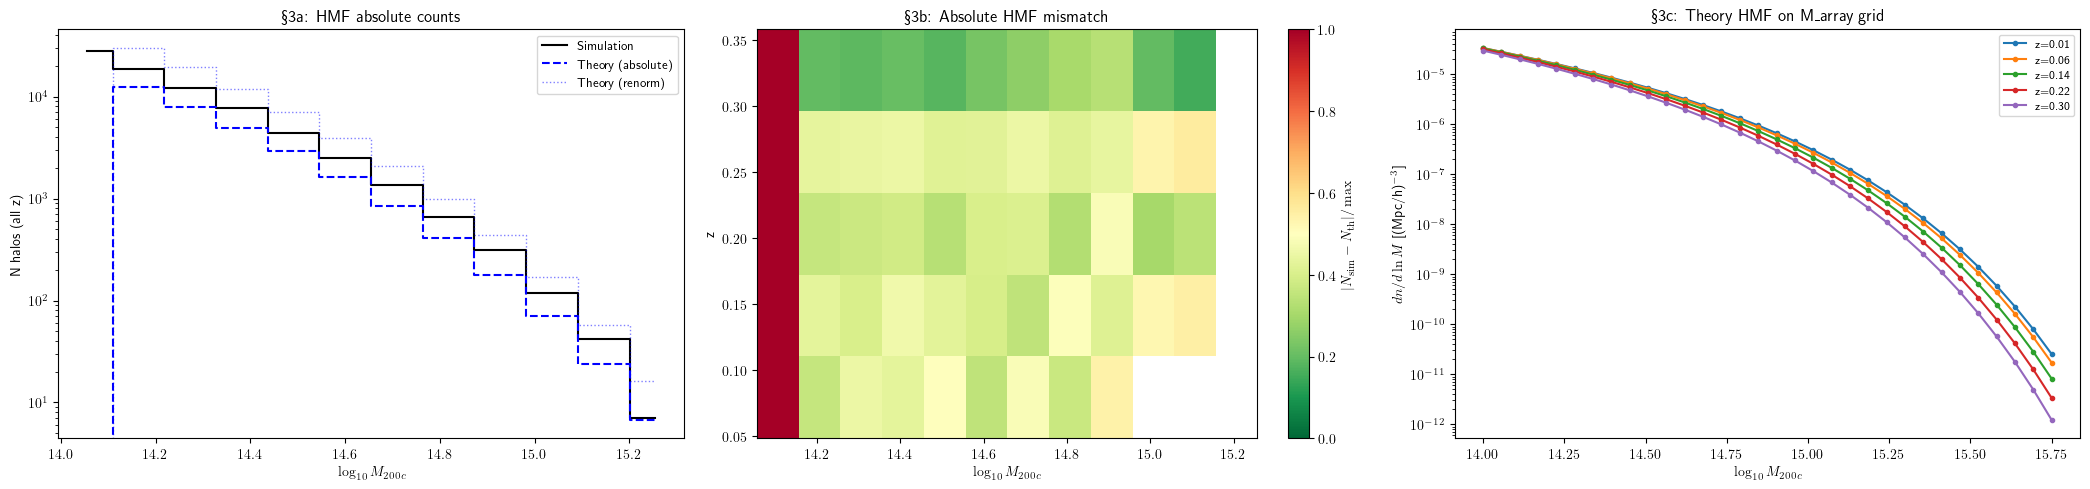

In [6]:
# §3: HMF — absolute theory vs simulation halo counts
hmf_diag = compare_sim_vs_theory_hmf(M200c_all, z_all, Cls_test)
hmf_Mz = np.array(Cls_test.hmf_Mz_mat)  # (nz, nM) = dn/dlnM in (Mpc/h)^{-3}

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Panel 1: absolute HMF comparison (z-summed)
sim_M = hmf_diag['sim_counts'].sum(axis=0)
th_M_abs = hmf_diag['theory_counts_abs'].sum(axis=0)
th_M_norm = hmf_diag['theory_counts_norm'].sum(axis=0)
axes[0].step(hmf_diag['logM_cen'], sim_M, where='mid', color='k', lw=1.5, label='Simulation')
axes[0].step(hmf_diag['logM_cen'], th_M_abs, where='mid', color='b', lw=1.5, ls='--', label='Theory (absolute)')
axes[0].step(hmf_diag['logM_cen'], th_M_norm, where='mid', color='b', lw=1.0, ls=':', alpha=0.5, label='Theory (renorm)')
axes[0].set(xlabel=r'$\log_{10} M_{200c}$', ylabel='N halos (all z)',
            title='§3a: HMF absolute counts', yscale='log')
axes[0].legend(fontsize=9)

# Panel 2: absolute fractional mismatch heatmap
fm = hmf_diag['frac_mismatch_abs']
im = axes[1].imshow(fm, origin='lower', aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1.0,
                    extent=[hmf_diag['logM_cen'][0], hmf_diag['logM_cen'][-1],
                            hmf_diag['z_cen'][0], hmf_diag['z_cen'][-1]])
axes[1].set(xlabel=r'$\log_{10} M_{200c}$', ylabel='z', title='§3b: Absolute HMF mismatch')
plt.colorbar(im, ax=axes[1], label=r'$|N_{\rm sim} - N_{\rm th}|/\max$')

# Panel 3: theory dn/dlnM at a few z slices to check resolution
for jz in z_sel:
    axes[2].plot(logM_th, hmf_Mz[jz], '-o', ms=3, label=f'z={z_th[jz]:.2f}')
axes[2].set(xlabel=r'$\log_{10} M_{200c}$', ylabel=r'$dn/d\ln M$ [(Mpc/h)$^{-3}$]',
            title='§3c: Theory HMF on M\\_array grid', yscale='log')
axes[2].legend(fontsize=8)
plt.tight_layout()

# Print total counts
total_sim = hmf_diag['sim_counts'].sum()
total_th = hmf_diag['theory_counts_abs'].sum()
print(f"\nTotal sim halos: {total_sim:.0f}")
print(f"Total theory halos (absolute): {total_th:.0f}")
if total_th > 0:
    print(f"Ratio sim/theory: {total_sim / total_th:.4f}")
print(f"\nM_array: {len(M_th)} points from 10^{logM_th[0]:.2f} to 10^{logM_th[-1]:.2f}")
print(f"dlnM spacing: {np.diff(np.log(M_th)).mean():.4f} (dex: {np.diff(logM_th).mean():.4f})")

## §4 — Baryonic suppression factor `Pmm_sup_tot_mat` applied to P_gg

The code computes:
```
Pmm_sup_tot_mat = phfit_kz_mat / Pmm_nfw_tot_mat
Pgg_tot_mat = (Pgg_1h + Pgg_2h) * Pmm_sup_tot_mat
```

This "response" factor corrects the halo-model total matter power to match Halofit.
**But applying it to Pgg is physically questionable** — the galaxy field has different scale dependence than matter.

If `Pmm_sup_tot_mat` deviates significantly from 1 at the ell-ranges of interest, it could cause a scale-dependent bias in the theory Cl_gg.

z=0.01: Pmm_sup in ell=[100,1200] → k=[6.601,78.856]: min=3.140, max=36.994, median=8.490
z=0.06: Pmm_sup in ell=[100,1200] → k=[0.586,6.997]: min=1.210, max=2.747, median=1.805
z=0.14: Pmm_sup in ell=[100,1200] → k=[0.252,3.011]: min=0.973, max=2.208, median=1.321
z=0.22: Pmm_sup in ell=[100,1200] → k=[0.163,1.948]: min=0.945, max=1.752, median=1.142
z=0.30: Pmm_sup in ell=[100,1200] → k=[0.122,1.456]: min=0.937, max=1.560, median=1.063


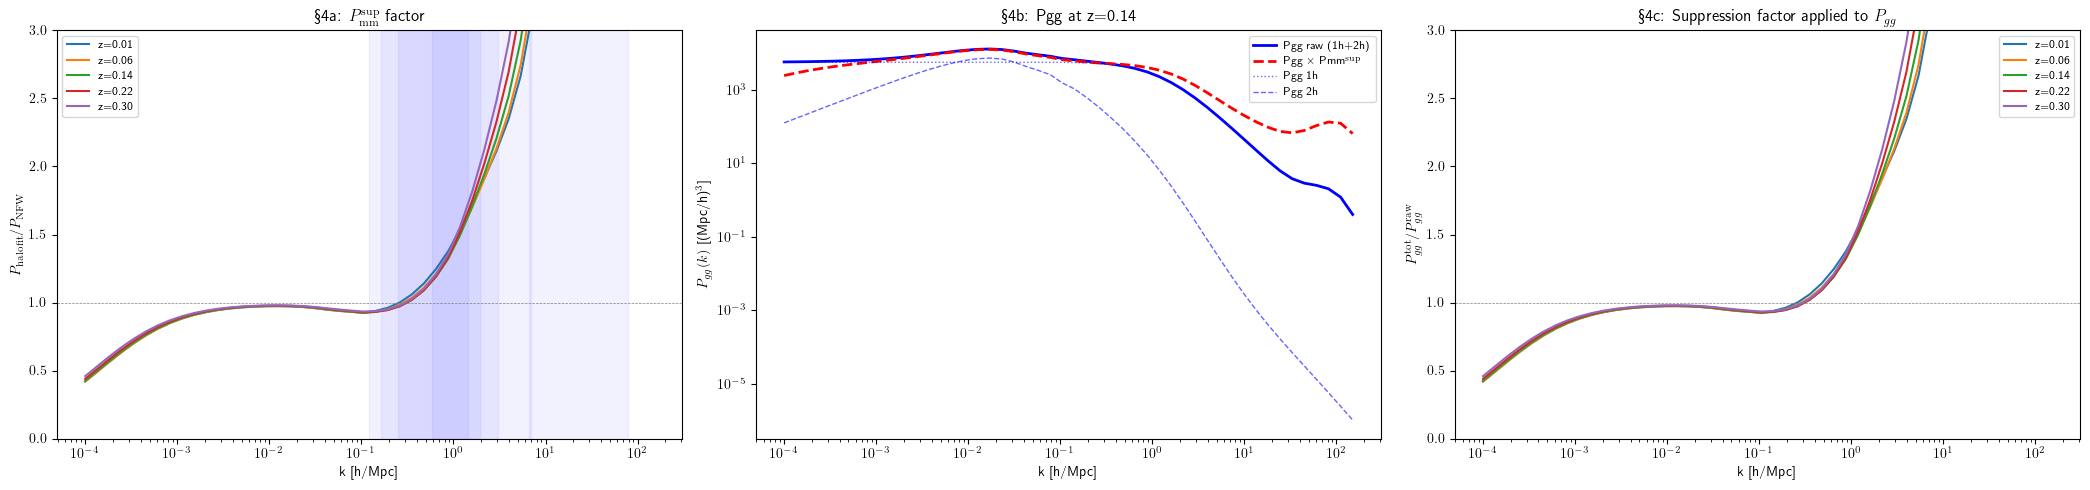

In [7]:
# §4: Inspect Pmm_sup_tot_mat and its effect on Pgg

Pmm_sup = np.array(Cls_test.Pmm_sup_tot_mat)  # (nk, nz)
kPk = np.array(Cls_test.kPk_array)

Pgg_1h = np.array(Cls_test.Pgg_1h_kz_mat)   # (nk, nz)
Pgg_2h = np.array(Cls_test.Pgg_2h_kz_mat)   # (nk, nz)
Pgg_raw = Pgg_1h + Pgg_2h                     # before suppression
Pgg_tot = np.array(Cls_test.Pgg_tot_mat)      # after suppression = Pgg_raw * Pmm_sup

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Panel 1: Pmm_sup at several z
for jz in z_sel:
    axes[0].plot(kPk, Pmm_sup[:, jz], label=f'z={z_th[jz]:.2f}')
axes[0].axhline(1.0, color='gray', ls='--', lw=0.5)
axes[0].set(xscale='log', xlabel='k [h/Mpc]', ylabel=r'$P_{\rm halofit}/P_{\rm NFW}$',
            title=r'§4a: $P_{\rm mm}^{\rm sup}$ factor', ylim=(0, 3))
axes[0].legend(fontsize=8)

# Mark the k range probed by ell = [100, 1200] at relevant z
chi_arr = np.array(Cls_test.chi_array)
for jz in z_sel:
    k_lo = 100.5 / max(chi_arr[jz], 1.0)
    k_hi = 1200.5 / max(chi_arr[jz], 1.0)
    axes[0].axvspan(k_lo, k_hi, alpha=0.05, color='blue')

# Panel 2: Pgg with and without suppression
jz_mid = z_sel[len(z_sel)//2]
axes[1].loglog(kPk, Pgg_raw[:, jz_mid], 'b-', lw=2, label='Pgg raw (1h+2h)')
axes[1].loglog(kPk, Pgg_tot[:, jz_mid], 'r--', lw=2, label=r'Pgg $\times$ Pmm$^{\rm sup}$')
axes[1].loglog(kPk, Pgg_1h[:, jz_mid], 'b:', lw=1, alpha=0.6, label='Pgg 1h')
axes[1].loglog(kPk, Pgg_2h[:, jz_mid], 'b--', lw=1, alpha=0.6, label='Pgg 2h')
axes[1].set(xlabel='k [h/Mpc]', ylabel=r'$P_{gg}(k)$ [(Mpc/h)$^3$]',
            title=f'§4b: Pgg at z={z_th[jz_mid]:.2f}')
axes[1].legend(fontsize=8)

# Panel 3: ratio Pgg_tot / Pgg_raw = Pmm_sup effect on galaxy power
for jz in z_sel:
    ratio_sup = np.where(Pgg_raw[:, jz] > 1e-30, Pgg_tot[:, jz] / Pgg_raw[:, jz], np.nan)
    axes[2].semilogx(kPk, ratio_sup, label=f'z={z_th[jz]:.2f}')
axes[2].axhline(1.0, color='gray', ls='--', lw=0.5)
axes[2].set(xlabel='k [h/Mpc]', ylabel=r'$P_{gg}^{\rm tot}/P_{gg}^{\rm raw}$',
            title=r'§4c: Suppression factor applied to $P_{gg}$', ylim=(0, 3))
axes[2].legend(fontsize=8)
plt.tight_layout()

# Print Pmm_sup statistics at relevant k range
for jz in z_sel:
    k_lo = 100.5 / max(chi_arr[jz], 1.0)
    k_hi = 1200.5 / max(chi_arr[jz], 1.0)
    k_mask = (kPk >= k_lo) & (kPk <= k_hi)
    if k_mask.any():
        sup_vals = Pmm_sup[k_mask, jz]
        print(f"z={z_th[jz]:.2f}: Pmm_sup in ell=[100,1200] → k=[{k_lo:.3f},{k_hi:.3f}]: "
              f"min={sup_vals.min():.3f}, max={sup_vals.max():.3f}, median={np.median(sup_vals):.3f}")

## §5 — Effective galaxy bias: simulation vs theory

The 2-halo term dominates at large scales (low ell). If the simulation galaxies have a different effective bias than theory predicts, the 2-halo amplitude will be wrong.

Theory bias:
```
bg(k,z) = (1/nbarz) * ∫ dlnM [Ncen + Nsat*uk_clm] * b(M,z) * dn/dlnM
P_gg^2h = bg^2 * P_lin
```

Simulation bias: measured from `Cl_gg_meas / Cl_mm_theory` at large scales, or from the mock galaxy catalog cross-correlated with theory.

Effective bias ratio at ell=[100,300]: Cl_meas/Cl_th = 22.179
  → implies b_eff(sim)/b_eff(th) = 4.709
  Theory large-scale bias (z-weighted mean in active bins): 0.694


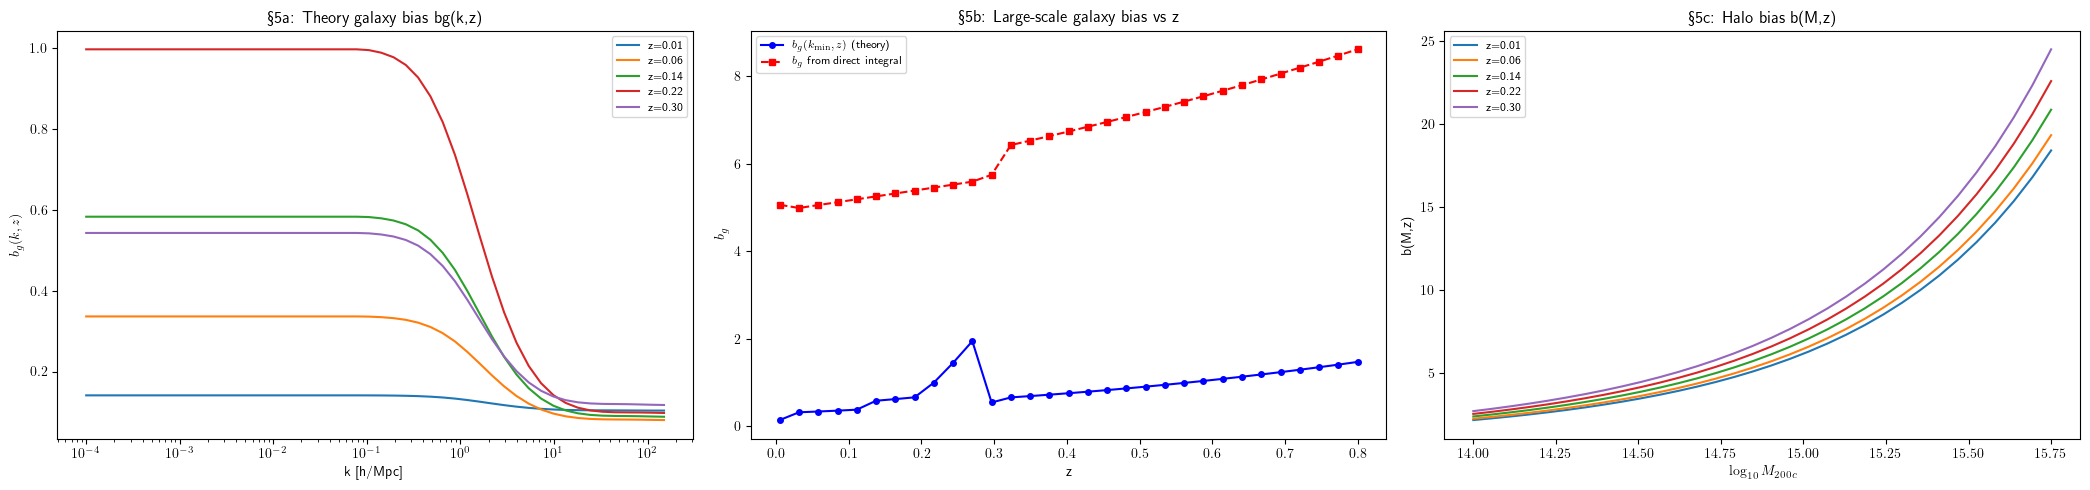

In [8]:
# §5: Galaxy bias — theory bg(k,z) vs effective bias from simulation

bg_kz = np.array(Cls_test.bg_kz_mat)  # (nk, nz)
bias_Mz = np.array(Cls_test.bias_Mz_mat)  # (nz, nM) — halo bias b(M,z)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Panel 1: theory bg(k,z) — k-dependent effective galaxy bias
for jz in z_sel:
    axes[0].semilogx(kPk, bg_kz[:, jz], label=f'z={z_th[jz]:.2f}')
axes[0].set(xlabel='k [h/Mpc]', ylabel=r'$b_g(k,z)$',
            title='§5a: Theory galaxy bias bg(k,z)')
axes[0].legend(fontsize=8)

# Panel 2: large-scale bias b_g(k→0) vs z
# Use the lowest k bin as proxy for large-scale bias
bg_largescale = bg_kz[0, :]  # k_min
axes[1].plot(z_th, bg_largescale, 'b-o', ms=4, label=r'$b_g(k_{\rm min}, z)$ (theory)')

# Estimate effective bias from simulation: b_eff = sqrt(Cl_gg / Cl_mm) at large ell
# Use theory Cl_mm (kappa-kappa / lensing) as reference
# For a simpler estimate: b_eff^2 ≈ Σ_M [N_cen(M)+N_sat(M)] * b(M) * dn/dlnM / nbarz
bg_simple = np.zeros(len(z_th))
for jz in range(len(z_th)):
    if nbar_realized[jz] > 1e-15:
        integrand = (Ncen_mat[jz] + Nsat_mat[jz]) * bias_Mz[jz] * hmf_Mz[jz]
        bg_simple[jz] = np.trapz(integrand, np.log(M_th)) / nbar_realized[jz]
axes[1].plot(z_th, bg_simple, 'r--s', ms=4, label=r'$b_g$ from direct integral')
axes[1].set(xlabel='z', ylabel=r'$b_g$', title='§5b: Large-scale galaxy bias vs z')
axes[1].legend(fontsize=8)

# Panel 3: halo bias b(M,z) to understand mass weighting
for jz in z_sel:
    axes[2].plot(logM_th, bias_Mz[jz], label=f'z={z_th[jz]:.2f}')
axes[2].set(xlabel=r'$\log_{10} M_{200c}$', ylabel='b(M,z)',
            title='§5c: Halo bias b(M,z)')
axes[2].legend(fontsize=8)
plt.tight_layout()

# Estimate effective bias from measured Cl ratio at low ell
# b_eff^2 ≈ Cl_gg_meas / Cl_gg_theory * b_g_theory^2
# Or simply: at ell~200, what bias is implied by the measured power?
Cl_th_at_ell = interp1d(ell_th, Cl_th, bounds_error=False, fill_value=np.nan)(ell)
ell_mask = (ell >= 100) & (ell <= 300) & (Cl_gg_no_shot > 0) & np.isfinite(Cl_th_at_ell) & (Cl_th_at_ell > 0)
if ell_mask.any():
    ratio_2h = np.mean(Cl_gg_no_shot[ell_mask] / Cl_th_at_ell[ell_mask])
    print(f"Effective bias ratio at ell=[100,300]: Cl_meas/Cl_th = {ratio_2h:.3f}")
    print(f"  → implies b_eff(sim)/b_eff(th) = {np.sqrt(ratio_2h):.3f}")
    print(f"  Theory large-scale bias (z-weighted mean in active bins): {bg_largescale[active].mean():.3f}")

## §6 — Satellite radial profile and 1-halo term

The 1-halo term uses:
```
P_gg^1h = ∫ dlnM [2*Ncen*Nsat*uk_clm + (Nsat*uk_clm)^2] / nbarz^2 * dn/dlnM
```

where `uk_clm` is the FFTlog transform of the CLM (collisionless matter) density profile,
normalized by M_clm at the outer radius.

The simulation draws satellite radii from the same CLM profile via PPF table inversion.
If the FFTlog uk_clm differs from the real-space profile used in the simulation (e.g., due to truncation, resolution, or extrapolation), the 1h power will be off at high ell.

1h-2h transition ell ≈ 1500
At ell=200 (2h regime): 2h fraction = 0.04
At ell=1000 (1h regime): 1h fraction = 0.96


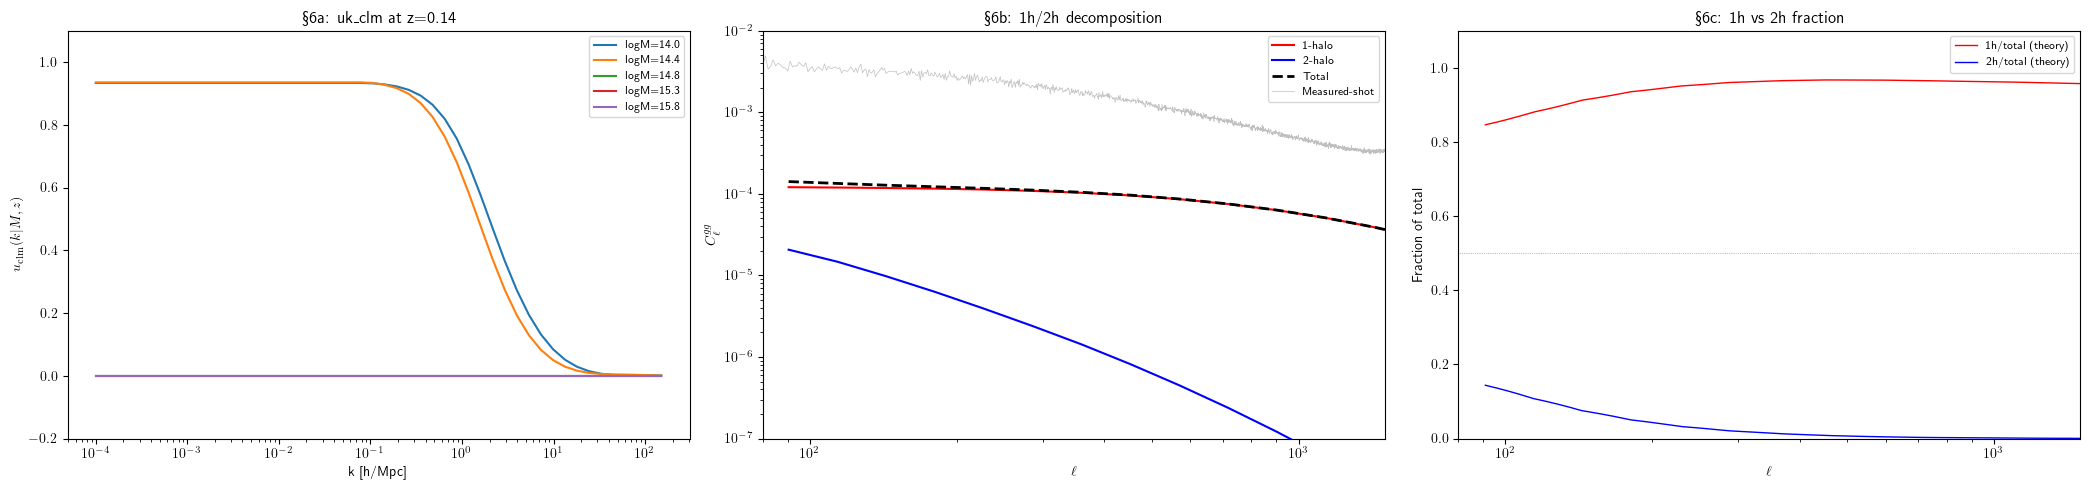

In [9]:
# §6: Satellite profile — uk_clm in Fourier space and 1h/2h decomposition

uk_clm = np.array(Cls_test.uk_clm)  # (nk, nz, nM)
ukg_cross = np.array(Cls_test.ukg_cross)  # (nk, nz, nM)
ukg_auto_sqr = np.array(Cls_test.ukg_auto_sqr)  # (nk, nz, nM)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Panel 1: uk_clm at a few (z, M) values
jz_mid = z_sel[len(z_sel)//2]
M_sel = np.linspace(0, len(M_th)-1, 5).astype(int)
for jM in M_sel:
    axes[0].semilogx(kPk, uk_clm[:, jz_mid, jM], label=f'logM={logM_th[jM]:.1f}')
axes[0].set(xlabel='k [h/Mpc]', ylabel=r'$u_{\rm clm}(k|M,z)$',
            title=f'§6a: uk\\_clm at z={z_th[jz_mid]:.2f}', ylim=(-0.2, 1.1))
axes[0].legend(fontsize=8)

# Panel 2: 1h/2h decomposition of Cl_gg
cl_decomp = compute_Cl_gg_1h_2h(Cls_test)
axes[1].loglog(cl_decomp['ell'], cl_decomp['Cl_1h'], 'r-', lw=1.5, label='1-halo')
axes[1].loglog(cl_decomp['ell'], cl_decomp['Cl_2h'], 'b-', lw=1.5, label='2-halo')
axes[1].loglog(cl_decomp['ell'], cl_decomp['Cl_tot'], 'k--', lw=2, label='Total')
axes[1].loglog(ell, np.maximum(Cl_gg_no_shot, 1e-12), 'gray', alpha=0.5, lw=0.5, label='Measured-shot')
axes[1].set(xlabel=r'$\ell$', ylabel=r'$C_\ell^{gg}$', xlim=(80, 1500), ylim=(1e-7, 1e-2),
            title='§6b: 1h/2h decomposition')
axes[1].legend(fontsize=8)

# Panel 3: ratio of measured/theory for 1h-dominated and 2h-dominated regions
# At low ell, 2h dominates → excess implies bias issue
# At high ell, 1h dominates → deficit implies profile/shot noise issue
Cl_1h_interp = interp1d(cl_decomp['ell'], cl_decomp['Cl_1h'], bounds_error=False, fill_value=np.nan)(ell)
Cl_2h_interp = interp1d(cl_decomp['ell'], cl_decomp['Cl_2h'], bounds_error=False, fill_value=np.nan)(ell)
frac_1h = np.where(Cl_th_at_ell > 0, Cl_1h_interp / Cl_th_at_ell, np.nan)

ell_plot_mask = (ell >= 80) & (ell <= 1500)
axes[2].semilogx(ell[ell_plot_mask], frac_1h[ell_plot_mask], 'r-', lw=1, label='1h/total (theory)')
frac_2h = np.where(Cl_th_at_ell > 0, Cl_2h_interp / Cl_th_at_ell, np.nan)
axes[2].semilogx(ell[ell_plot_mask], frac_2h[ell_plot_mask], 'b-', lw=1, label='2h/total (theory)')
axes[2].axhline(0.5, ls=':', color='gray', lw=0.5)
axes[2].set(xlabel=r'$\ell$', ylabel='Fraction of total', title='§6c: 1h vs 2h fraction',
            xlim=(80, 1500), ylim=(0, 1.1))
axes[2].legend(fontsize=8)
plt.tight_layout()

# Identify the transition ell where 1h ≈ 2h
trans_mask = (ell >= 80) & (ell <= 1500) & np.isfinite(Cl_1h_interp) & np.isfinite(Cl_2h_interp)
if trans_mask.any():
    diff_1h_2h = np.abs(Cl_1h_interp[trans_mask] - Cl_2h_interp[trans_mask])
    ell_trans = ell[trans_mask][np.argmin(diff_1h_2h)]
    print(f"1h-2h transition ell ≈ {ell_trans}")
    print(f"At ell=200 (2h regime): 2h fraction = {frac_2h[200]:.2f}")
    print(f"At ell=1000 (1h regime): 1h fraction = {frac_1h[1000]:.2f}")

## §7 — Shot noise and pixel window deconvolution

Two things can cause constant or ell-dependent offsets:

1. **Shot noise**: Theory has HOD-integral shot noise. Measured spectrum has map-level `1/nbar_sr` shot noise. If these differ, the subtracted spectrum is offset.

2. **Pixel window**: `hp.pixwin(nside)^2` deconvolution amplifies power at high ell but also amplifies noise. If the galaxy map has sub-pixel structure, pixwin deconvolution may be imperfect.

3. **`delta_gal = map_gal / mean(map_gal)`** — this divides by the map mean, not the true nbar. For sparse maps with many zero pixels this is correct (overdensity), but check normalization.

[HOD shot noise] Cl_shot (theory integral) = 1.1023e-04



Map statistics:
  Npix = 3145728, N_gal = 209490
  Empty pixels: 3045883 (96.8%)
  Mean galaxies/pixel: 0.0666
  Shot noise (map): 5.9986e-05
  Shot noise (HOD): 1.1023e-04
  Ratio HOD/map: 1.8375
  Shot noise difference: 5.0241e-05 (83.8% of map shot)


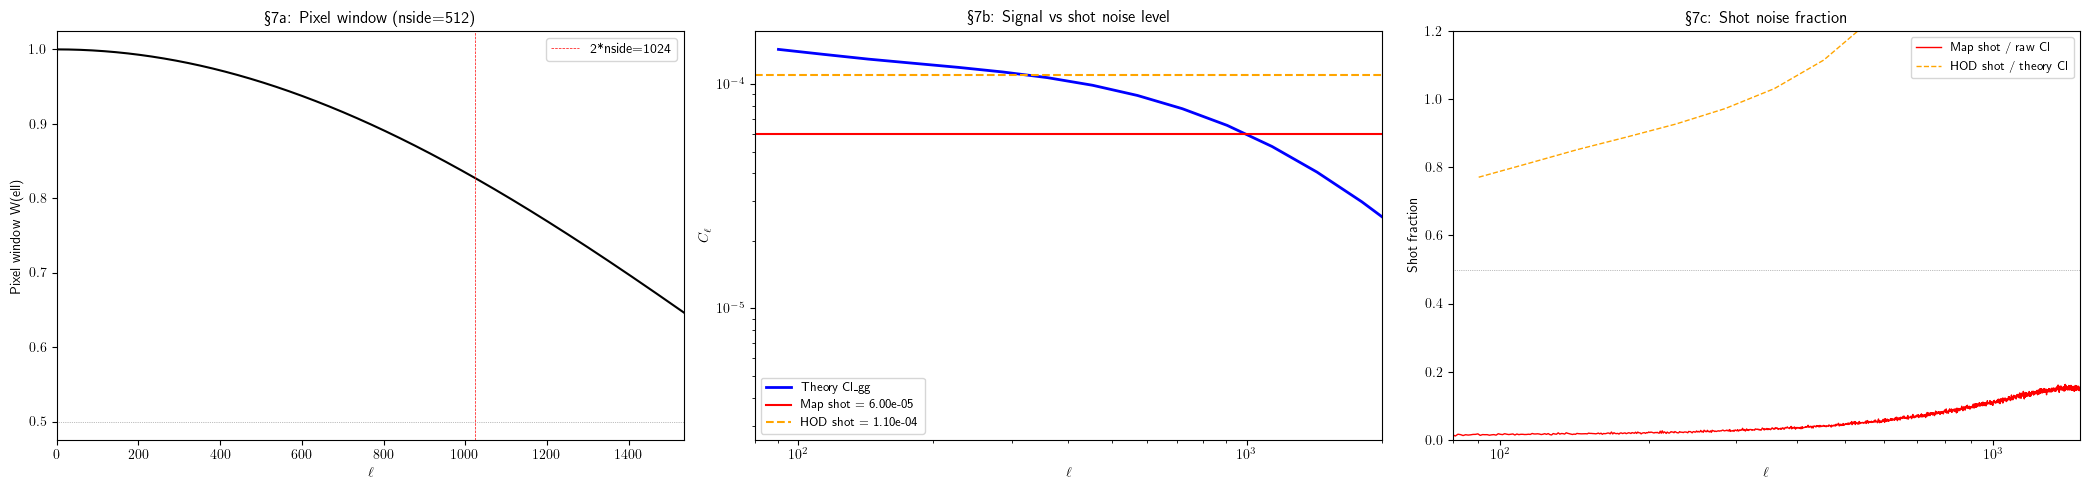

In [10]:
# §7: Shot noise and pixel window diagnostics

Cl_shot_hod = compute_hod_shot_noise_Cl(Cls_test)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Panel 1: pixel window function
pixwin_arr = hp.pixwin(nside)
ell_pw = np.arange(len(pixwin_arr))
axes[0].plot(ell_pw, pixwin_arr, 'k-', lw=1.5)
axes[0].set(xlabel=r'$\ell$', ylabel='Pixel window W(ell)',
            title=f'§7a: Pixel window (nside={nside})', xlim=(0, 3*nside))
axes[0].axhline(0.5, color='gray', ls=':', lw=0.5)
axes[0].axvline(2*nside, color='r', ls='--', lw=0.5, label=f'2*nside={2*nside}')
axes[0].legend()

# Panel 2: shot noise comparison
axes[1].plot(ell_th, Cl_th, 'b-', lw=2, label='Theory Cl\\_gg')
axes[1].axhline(Cl_shot, color='r', ls='-', lw=1.5, label=f'Map shot = {Cl_shot:.2e}')
axes[1].axhline(Cl_shot_hod, color='orange', ls='--', lw=1.5, label=f'HOD shot = {Cl_shot_hod:.2e}')
axes[1].set(xscale='log', yscale='log', xlabel=r'$\ell$', ylabel=r'$C_\ell$',
            xlim=(80, 2000), title='§7b: Signal vs shot noise level')
axes[1].legend(fontsize=9)

# Panel 3: what fraction of the raw Cl is shot noise?
frac_shot_map = np.where(Cl_gg_deconv > 0, Cl_shot / Cl_gg_deconv, np.nan)
frac_shot_hod = np.where(Cl_th > 0, Cl_shot_hod / Cl_th, np.nan)
ell_m = (ell >= 80) & (ell <= 1500)
axes[2].semilogx(ell[ell_m], frac_shot_map[ell_m], 'r-', lw=1, label='Map shot / raw Cl')
axes[2].semilogx(ell_th, frac_shot_hod, 'orange', ls='--', lw=1, label='HOD shot / theory Cl')
axes[2].axhline(0.5, ls=':', color='gray', lw=0.5)
axes[2].set(xlabel=r'$\ell$', ylabel='Shot fraction', ylim=(0, 1.2),
            xlim=(80, 1500), title='§7c: Shot noise fraction')
axes[2].legend(fontsize=9)
plt.tight_layout()

# Map statistics
npix = 12 * nside**2
n_empty = (map_gal == 0).sum()
mean_gal_per_pix = np.mean(map_gal)
print(f"\nMap statistics:")
print(f"  Npix = {npix}, N_gal = {n_gal}")
print(f"  Empty pixels: {n_empty} ({100*n_empty/npix:.1f}%)")
print(f"  Mean galaxies/pixel: {mean_gal_per_pix:.4f}")
print(f"  Shot noise (map): {Cl_shot:.4e}")
print(f"  Shot noise (HOD): {Cl_shot_hod:.4e}")
print(f"  Ratio HOD/map: {Cl_shot_hod/Cl_shot:.4f}")
print(f"  Shot noise difference: {abs(Cl_shot - Cl_shot_hod):.4e} "
      f"({100*abs(Cl_shot - Cl_shot_hod)/Cl_shot:.1f}% of map shot)")

## §8 — Limber integrand decomposition: where in z does the power come from?

The Cl_gg integral is:
```
C_ℓ^gg = ∫ dz [Wg/(dχ/dz · χ²)]² · χ² · dχ/dz · Pgg(ℓ/χ, z)
```

By plotting the integrand vs z at different ell, we can see:
- Which z range contributes most to the low-ell excess
- Whether the galaxy window Wg concentrates power at z where the HOD or HMF is unreliable
- Whether the high-ell deficit comes from a specific z range

z at which 50%/90% of Cl_gg integral is accumulated:
  ell= 120: z_50%=0.259, z_90%=0.277
  ell= 200: z_50%=0.259, z_90%=0.277
  ell= 500: z_50%=0.259, z_90%=0.277
  ell=1000: z_50%=0.259, z_90%=0.277


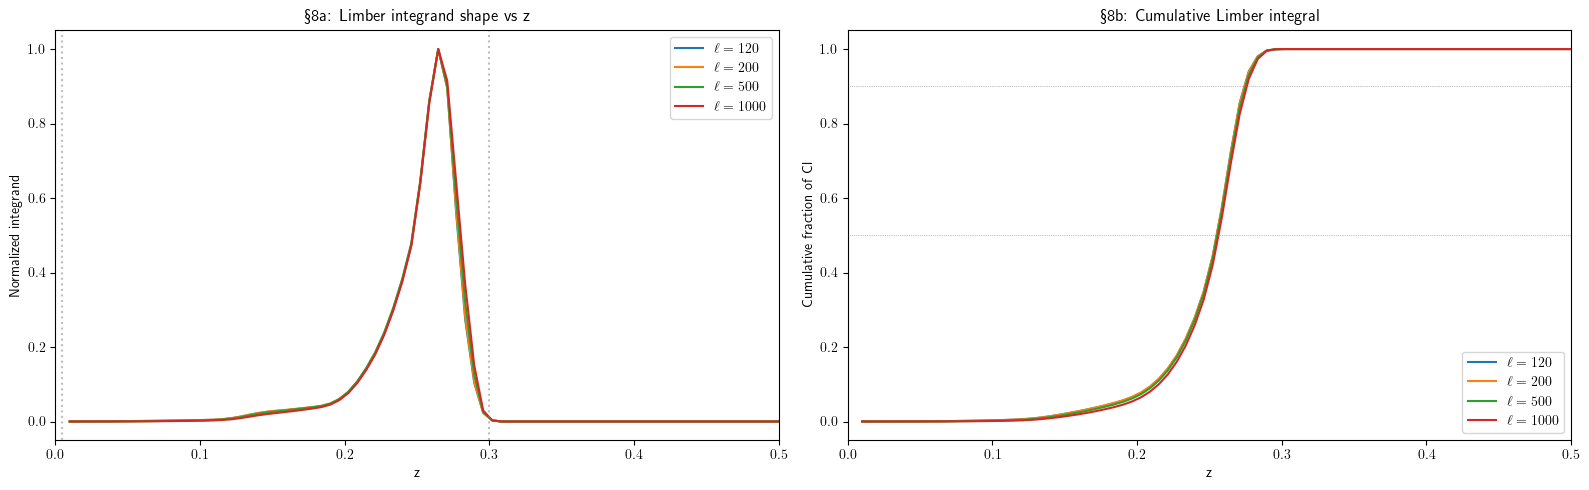

In [11]:
# §8: Limber integrand decomposition — where in z does the Cl_gg power come from?

chi_for_Cls = np.array(Cls_test.chi_array_for_Cls)
dchi_dz_for_Cls = np.array(Cls_test.dchi_dz_array_for_Cls)
Pkgg_lz = np.array(Cls_test.cached_power_spectra[2, 2])  # (nell, nz_for_Cls)

# Wg kernel prefactor: Wg / (dchi/dz * chi^2)
prefac_Wg = Wg_actual / (dchi_dz_for_Cls * chi_for_Cls**2)

# Limber integrand at selected ells
ell_targets = [120, 200, 500, 1000]
jl_targets = [np.argmin(np.abs(ell_th - et)) for et in ell_targets]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for jl, et in zip(jl_targets, ell_targets):
    Pgg_at_ell = Pkgg_lz[jl, :]  # Pgg(k=ell/chi, z) at each z_for_Cls point
    integrand = prefac_Wg**2 * chi_for_Cls**2 * dchi_dz_for_Cls * Pgg_at_ell
    # Normalize for shape comparison
    peak = integrand.max()
    if peak > 0:
        axes[0].plot(z_for_Cls, integrand / peak, label=fr'$\ell={et}$')

axes[0].set(xlabel='z', ylabel='Normalized integrand',
            title='§8a: Limber integrand shape vs z', xlim=(0, 0.5))
axes[0].legend(fontsize=10)
axes[0].axvline(gal_zmin, ls=':', color='gray', alpha=0.5)
axes[0].axvline(gal_zmax, ls=':', color='gray', alpha=0.5)

# Panel 2: cumulative fraction of the integral vs z
for jl, et in zip(jl_targets, ell_targets):
    Pgg_at_ell = Pkgg_lz[jl, :]
    integrand = prefac_Wg**2 * chi_for_Cls**2 * dchi_dz_for_Cls * Pgg_at_ell
    cumul = np.cumsum(integrand) * np.gradient(z_for_Cls)
    total = cumul[-1]
    if total > 0:
        axes[1].plot(z_for_Cls, cumul / total, label=fr'$\ell={et}$')

axes[1].set(xlabel='z', ylabel='Cumulative fraction of Cl',
            title='§8b: Cumulative Limber integral', xlim=(0, 0.5))
axes[1].axhline(0.5, ls=':', color='gray', lw=0.5)
axes[1].axhline(0.9, ls=':', color='gray', lw=0.5)
axes[1].legend(fontsize=10)
plt.tight_layout()

# Print the z at which 50% and 90% of the integral is reached
print("z at which 50%/90% of Cl_gg integral is accumulated:")
for jl, et in zip(jl_targets, ell_targets):
    Pgg_at_ell = Pkgg_lz[jl, :]
    integrand = prefac_Wg**2 * chi_for_Cls**2 * dchi_dz_for_Cls * Pgg_at_ell
    cumul = np.cumsum(integrand) * np.gradient(z_for_Cls)
    total = cumul[-1]
    if total > 0:
        z50 = z_for_Cls[np.searchsorted(cumul / total, 0.5)]
        z90 = z_for_Cls[np.searchsorted(cumul / total, 0.9)]
        print(f"  ell={et:4d}: z_50%={z50:.3f}, z_90%={z90:.3f}")

## §9 — Pgg(k,z) interpolation fidelity: theory grid vs Cls grid

The theory computes `Pgg_tot_mat` on the (kPk_array, z_array) grid, then uses `interpax.Interpolator2D` in (log ell, z) space to evaluate at the 128-point `z_array_for_Cls`.

If the z_array has only 31 points and the galaxy window is narrow (z < 0.3), there may be too few theory z-points inside the window, causing interpolation artifacts in `Pkgg_lz_mat`.

Theory z_array: 31 points, 12 inside [0.005, 0.3]
Cls z_array:    128 points, 47 inside [0.005, 0.3]
Theory z points inside galaxy window: [0.005  0.0315 0.058  0.0845 0.111  0.1375 0.164  0.1905 0.217  0.2435
 0.27   0.2965]



Pkgg_lz_mat (interpolated): shape=(20, 128), NaN=0, neg=0, zero=0


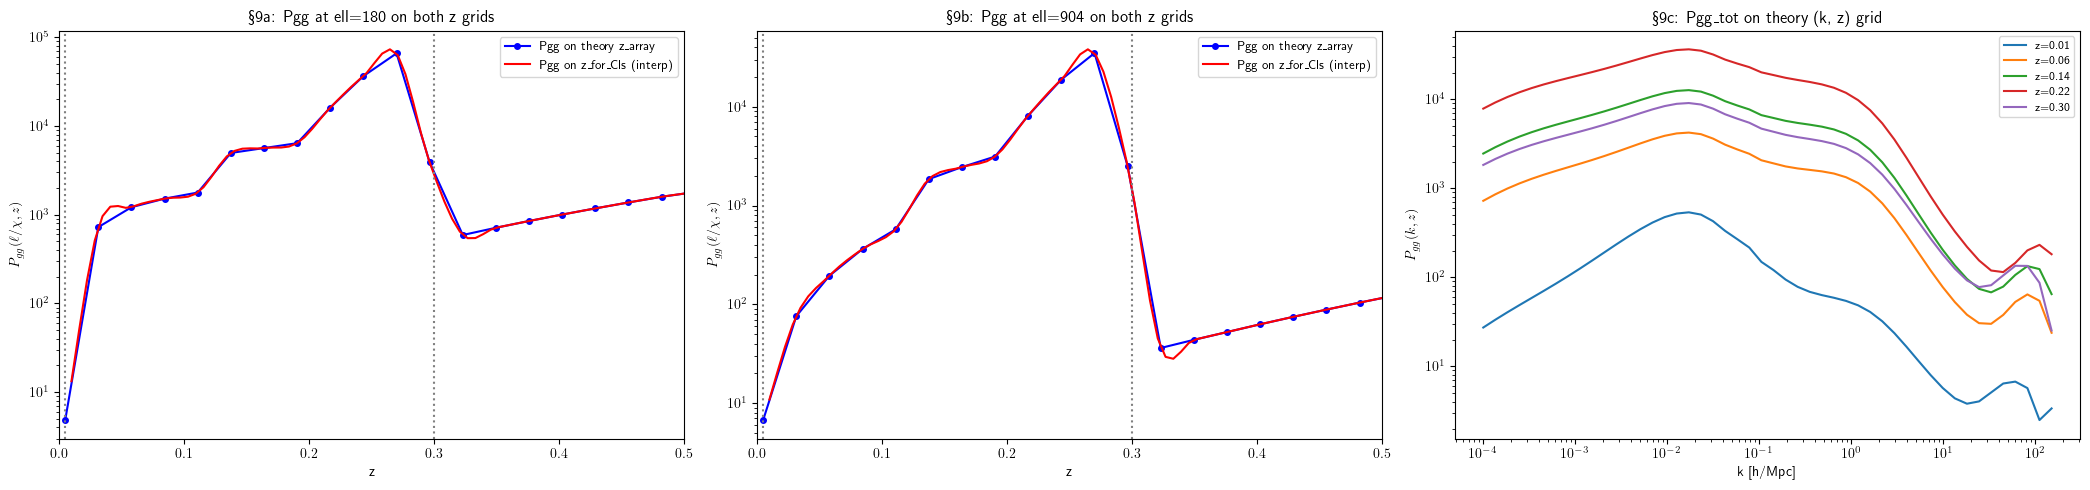

In [12]:
# §9: Pgg interpolation fidelity — theory z_array vs Cls z_array

# How many theory z-points fall inside the galaxy window?
z_in_window = (z_th >= gal_zmin) & (z_th <= gal_zmax)
z_in_window_Cls = (z_for_Cls >= gal_zmin) & (z_for_Cls <= gal_zmax)

print(f"Theory z_array: {len(z_th)} points, {z_in_window.sum()} inside [{gal_zmin}, {gal_zmax}]")
print(f"Cls z_array:    {len(z_for_Cls)} points, {z_in_window_Cls.sum()} inside [{gal_zmin}, {gal_zmax}]")
print(f"Theory z points inside galaxy window: {z_th[z_in_window]}")

# Compare Pgg on the theory grid vs the interpolated Cls grid
Pkgg_lz_mat = np.array(Cls_test.Pkgg_lz_mat)  # (nell, nz) — on theory z_array

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Panel 1: Pgg at a fixed ell on both z grids
jl_test = np.argmin(np.abs(ell_th - 200))
axes[0].plot(z_th, Pkgg_lz_mat[jl_test, :], 'bo-', ms=4, label='Pgg on theory z\\_array')
axes[0].plot(z_for_Cls, Pkgg_lz[jl_test, :], 'r-', lw=1.5, label='Pgg on z\\_for\\_Cls (interp)')
axes[0].axvline(gal_zmin, ls=':', color='gray')
axes[0].axvline(gal_zmax, ls=':', color='gray')
axes[0].set(xlabel='z', ylabel=r'$P_{gg}(\ell/\chi, z)$',
            title=f'§9a: Pgg at ell={ell_th[jl_test]:.0f} on both z grids',
            xlim=(0, 0.5), yscale='log')
axes[0].legend(fontsize=9)

# Panel 2: same at ell ~ 1000
jl_test2 = np.argmin(np.abs(ell_th - 1000))
axes[1].plot(z_th, Pkgg_lz_mat[jl_test2, :], 'bo-', ms=4, label='Pgg on theory z\\_array')
axes[1].plot(z_for_Cls, Pkgg_lz[jl_test2, :], 'r-', lw=1.5, label='Pgg on z\\_for\\_Cls (interp)')
axes[1].axvline(gal_zmin, ls=':', color='gray')
axes[1].axvline(gal_zmax, ls=':', color='gray')
axes[1].set(xlabel='z', ylabel=r'$P_{gg}(\ell/\chi, z)$',
            title=f'§9b: Pgg at ell={ell_th[jl_test2]:.0f} on both z grids',
            xlim=(0, 0.5), yscale='log')
axes[1].legend(fontsize=9)

# Panel 3: check that Pgg(k,z) on theory grid is smooth in k
for jz in z_sel:
    axes[2].loglog(kPk, Pgg_tot[:, jz], label=f'z={z_th[jz]:.2f}')
axes[2].set(xlabel='k [h/Mpc]', ylabel=r'$P_{gg}(k,z)$',
            title='§9c: Pgg\\_tot on theory (k, z) grid')
axes[2].legend(fontsize=8)
plt.tight_layout()

# Check for NaN or negative values in the interpolated Pgg
n_nan = np.isnan(Pkgg_lz).sum()
n_neg = (Pkgg_lz < 0).sum()
n_zero = (Pkgg_lz == 0).sum()
print(f"\nPkgg_lz_mat (interpolated): shape={Pkgg_lz.shape}, NaN={n_nan}, neg={n_neg}, zero={n_zero}")
if n_nan > 0 or n_neg > 0:
    print("  WARNING: NaN or negative values in interpolated Pgg — check log-interpolation!")

## §10 — Sensitivity test: Cl_gg with vs without Pmm_sup correction

To isolate the effect of the baryonic suppression factor on the theory Cl_gg, we recompute the Limber integral using `Pgg_raw = Pgg_1h + Pgg_2h` (without Pmm_sup) and compare.

Pmm_sup effect on Cl_gg:
  ell [100, 300]: mean ratio = 0.9887
  ell [300, 700]: mean ratio = 1.2102
  ell [700, 1200]: mean ratio = 1.6068


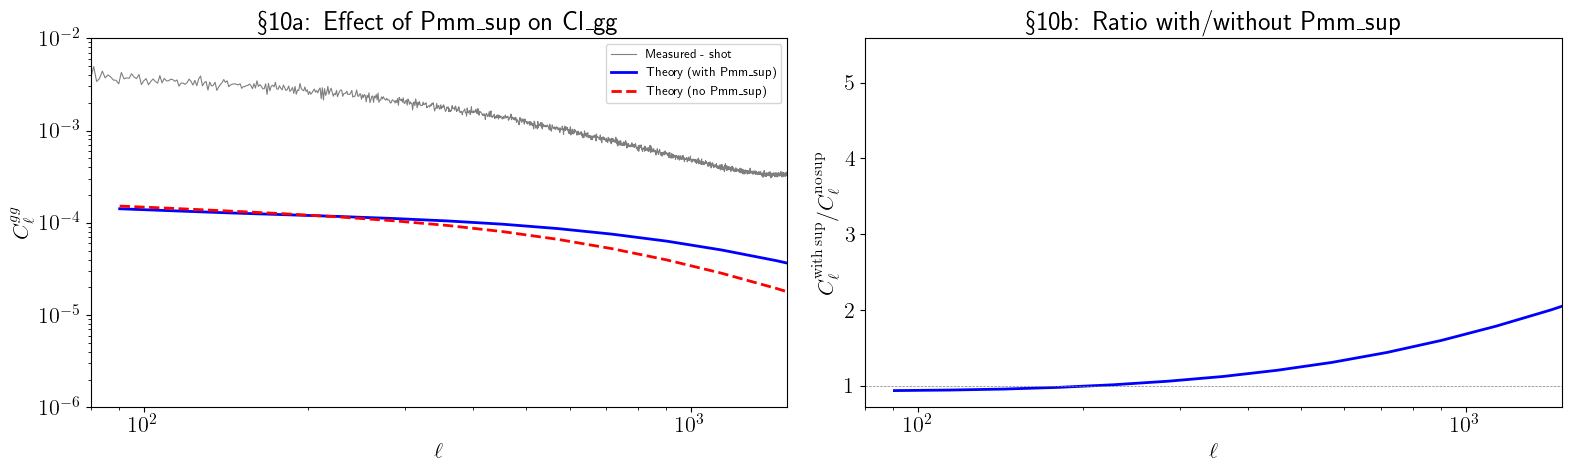

In [16]:
# §10: Recompute Cl_gg without Pmm_sup to see its effect
# We do a simplified Limber integral using the same logic as compute_Cl_gg_1h_2h
# but with Pgg_raw (no suppression) vs Pgg_tot (with suppression)

z_arr_Cls = np.array(Cls_test.z_array_for_Cls)
chi_Cls = np.array(Cls_test.chi_array_for_Cls)
dchi_dz_Cls = np.array(Cls_test.dchi_dz_array_for_Cls)
Wg = np.array(Cls_test.Wg_mat[0])
prefac = Wg / (dchi_dz_Cls * chi_Cls**2)

z_grid = np.array(Cls_test.z_array)

Cl_with_sup = np.zeros(len(ell_th))
Cl_no_sup = np.zeros(len(ell_th))

for jl, ell_val in enumerate(ell_th):
    Pkz_with = np.zeros(len(z_arr_Cls))
    Pkz_without = np.zeros(len(z_arr_Cls))
    for jz_c in range(len(z_arr_Cls)):
        chi_z = chi_Cls[jz_c]
        k_ell = (ell_val + 0.5) / max(chi_z, 1.0)
        jz_grid = np.argmin(np.abs(z_grid - z_arr_Cls[jz_c]))
        log_k = np.log(k_ell)
        log_kPk = np.log(kPk)
        # With suppression
        Pkz_with[jz_c] = np.exp(np.interp(
            log_k, log_kPk, np.log(np.clip(Pgg_tot[:, jz_grid], 1e-30, None))))
        # Without suppression
        Pkz_without[jz_c] = np.exp(np.interp(
            log_k, log_kPk, np.log(np.clip(Pgg_raw[:, jz_grid], 1e-30, None))))

    integrand_with = prefac**2 * chi_Cls**2 * dchi_dz_Cls * Pkz_with
    integrand_without = prefac**2 * chi_Cls**2 * dchi_dz_Cls * Pkz_without
    Cl_with_sup[jl] = np.trapz(integrand_with, z_arr_Cls)
    Cl_no_sup[jl] = np.trapz(integrand_without, z_arr_Cls)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Cl_gg with and without suppression vs measured
axes[0].loglog(ell, np.maximum(Cl_gg_no_shot, 1e-12), 'k-', lw=0.8, alpha=0.5, label='Measured - shot')
axes[0].loglog(ell_th, Cl_with_sup, 'b-', lw=2, label='Theory (with Pmm\\_sup)')
axes[0].loglog(ell_th, Cl_no_sup, 'r--', lw=2, label='Theory (no Pmm\\_sup)')
axes[0].set(xlim=(80, 1500), ylim=(1e-6, 1e-2), xlabel=r'$\ell$', ylabel=r'$C_\ell^{gg}$',
            title='§10a: Effect of Pmm\\_sup on Cl\\_gg')
axes[0].legend(fontsize=9)

# Panel 2: ratio
ratio_sup = np.where(Cl_no_sup > 0, Cl_with_sup / Cl_no_sup, np.nan)
axes[1].semilogx(ell_th, ratio_sup, 'b-', lw=2)
axes[1].axhline(1.0, color='gray', ls='--', lw=0.5)
axes[1].set(xlabel=r'$\ell$', ylabel=r'$C_\ell^{\rm with\,sup} / C_\ell^{\rm no\,sup}$',
            title='§10b: Ratio with/without Pmm\\_sup', xlim=(80, 1500))
plt.tight_layout()

print(f"Pmm_sup effect on Cl_gg:")
for lo, hi in [(100, 300), (300, 700), (700, 1200)]:
    m = (ell_th >= lo) & (ell_th <= hi)
    if m.any():
        print(f"  ell [{lo}, {hi}]: mean ratio = {ratio_sup[m].mean():.4f}")




## §11 — Comprehensive ratio overview and verdict

[Cl ratio diagnostics]
  ell [ 100,  300]: <Cl_meas/Cl_th> = 22.179
  ell [ 300,  700]: <Cl_meas/Cl_th> = 13.382
  ell [ 700, 1200]: <Cl_meas/Cl_th> = 8.390
  DIAGNOSTIC VERDICT

  Band ratios (Cl_meas - shot) / Cl_th:
    ell [ 100,  300]: 22.179  [HIGH]
    ell [ 300,  700]: 13.382  [HIGH]
    ell [ 700, 1200]: 8.390  [HIGH]

  n(z) shape consistency:
    max frac diff = 1.0000

  HOD:
    Ncen mismatch: max=10838.313
    Nsat mismatch: max=125592.384

  Mthresh boundary: FLAGGED

  HMF absolute (sim/theory ratio): 2.427

  Shot noise: map=5.999e-05, HOD=1.102e-04, ratio=1.838

  Pmm_sup effect:
    ell [100, 300]: 0.9887
    ell [300, 700]: 1.2102
    ell [700, 1200]: 1.6068

  z-grid resolution: 12 theory z-points in galaxy window


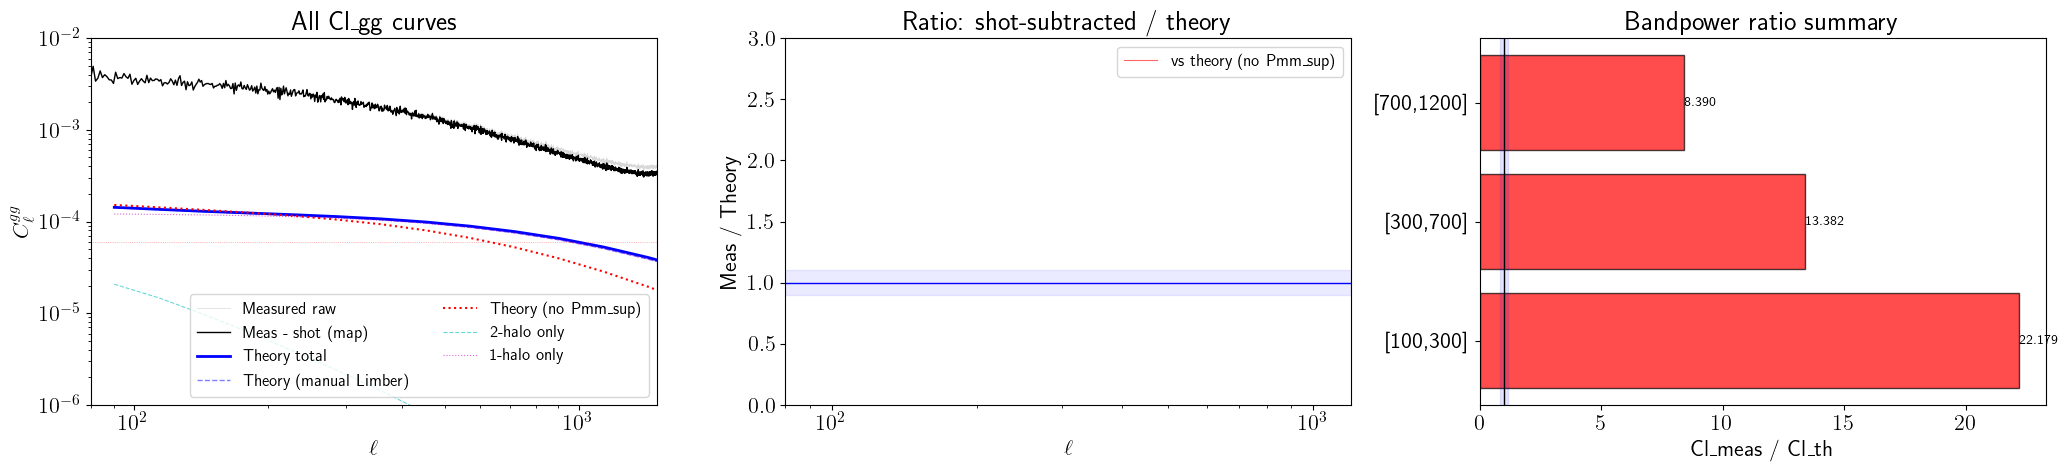

In [18]:
# §11: Final summary — all ratio diagnostics in one figure

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Panel 1: Cl_gg measured vs all theory variants
axes[0].loglog(ell, Cl_gg_deconv, 'gray', alpha=0.3, lw=0.5, label='Measured raw')
axes[0].loglog(ell, np.maximum(Cl_gg_no_shot, 1e-12), 'k-', lw=1, label='Meas - shot (map)')
axes[0].loglog(ell_th, Cl_th, 'b-', lw=2, label='Theory total')
axes[0].loglog(ell_th, Cl_with_sup, 'b--', lw=1, alpha=0.5, label='Theory (manual Limber)')
axes[0].loglog(ell_th, Cl_no_sup, 'r:', lw=1.5, label='Theory (no Pmm\\_sup)')
axes[0].loglog(cl_decomp['ell'], cl_decomp['Cl_2h'], 'c--', lw=0.8, alpha=0.6, label='2-halo only')
axes[0].loglog(cl_decomp['ell'], cl_decomp['Cl_1h'], 'm:', lw=0.8, alpha=0.6, label='1-halo only')
axes[0].axhline(Cl_shot, color='r', ls=':', lw=0.5, alpha=0.5)
axes[0].set(xlim=(80, 1500), ylim=(1e-6, 1e-2), xlabel=r'$\ell$', ylabel=r'$C_\ell^{gg}$',
            title='All Cl\\_gg curves')
axes[0].legend(fontsize=12, ncol=2)

# Panel 2: ratio (shot-subtracted / theory) with error bands
ratio_meas = np.where(Cl_th_at_ell > 0, Cl_gg_no_shot / Cl_th_at_ell, np.nan)
mask_r = (ell >= 80) & (ell <= 1200) & (Cl_gg_no_shot > 0) & np.isfinite(ratio_meas)
axes[1].plot(ell[mask_r], ratio_meas[mask_r], 'k-', lw=0.8)
axes[1].axhline(1.0, color='b', ls='-', lw=1)
axes[1].axhspan(0.9, 1.1, alpha=0.08, color='blue')

# Also show the ratio using the no-sup theory
Cl_no_sup_at_ell = interp1d(ell_th, Cl_no_sup, bounds_error=False, fill_value=np.nan)(ell)
ratio_nosup = np.where(Cl_no_sup_at_ell > 0, Cl_gg_no_shot / Cl_no_sup_at_ell, np.nan)
axes[1].plot(ell[mask_r], ratio_nosup[mask_r], 'r-', lw=0.8, alpha=0.6, label='vs theory (no Pmm\\_sup)')
axes[1].set(xscale='log', xlabel=r'$\ell$', ylabel='Meas / Theory',
            xlim=(80, 1200), ylim=(0, 3), title='Ratio: shot-subtracted / theory')
axes[1].legend(fontsize=12)

# Panel 3: bandpower ratios summary
band_ratios_gg = compute_Cl_ratio_in_bands(ell, np.maximum(Cl_gg_no_shot, 1e-20), ell_th, Cl_th)

bands = list(band_ratios_gg.keys())
ratios = [band_ratios_gg[b] for b in bands]
labels = [f'[{b[0]},{b[1]}]' for b in bands]
colors = ['red' if abs(r - 1) > 0.15 else 'green' for r in ratios]
axes[2].barh(labels, ratios, color=colors, alpha=0.7, edgecolor='k')
axes[2].axvline(1.0, color='k', ls='-', lw=1)
axes[2].axvspan(0.85, 1.15, alpha=0.1, color='blue')
axes[2].set(xlabel='Cl\\_meas / Cl\\_th', title='Bandpower ratio summary')
for i, r in enumerate(ratios):
    axes[2].text(r + 0.02, i, f'{r:.3f}', va='center', fontsize=10)
plt.tight_layout()

# Print comprehensive verdict
print("=" * 70)
print("  DIAGNOSTIC VERDICT")
print("=" * 70)
print(f"\n  Band ratios (Cl_meas - shot) / Cl_th:")
for (lo, hi), r in band_ratios_gg.items():
    status = "OK" if abs(r - 1) < 0.15 else ("HIGH" if r > 1 else "LOW")
    print(f"    ell [{lo:4d}, {hi:4d}]: {r:.3f}  [{status}]")

print(f"\n  n(z) shape consistency:")
if mask_nz.any():
    print(f"    max frac diff = {frac_nz.max():.4f}")

print(f"\n  HOD:")
if valid_cen.any():
    print(f"    Ncen mismatch: max={np.nanmax(hod_diag['frac_mismatch_Ncen']):.3f}")
if valid_sat.any():
    print(f"    Nsat mismatch: max={np.nanmax(hod_diag['frac_mismatch_Nsat']):.3f}")

print(f"\n  Mthresh boundary: {'FLAGGED' if boundary.any() else 'OK'}")

print(f"\n  HMF absolute (sim/theory ratio): {total_sim / total_th:.3f}" if total_th > 0 else "")

print(f"\n  Shot noise: map={Cl_shot:.3e}, HOD={Cl_shot_hod:.3e}, ratio={Cl_shot_hod/Cl_shot:.3f}")

print(f"\n  Pmm_sup effect:")
for lo, hi in [(100, 300), (300, 700), (700, 1200)]:
    m = (ell_th >= lo) & (ell_th <= hi)
    if m.any():
        print(f"    ell [{lo}, {hi}]: {ratio_sup[m].mean():.4f}")

print(f"\n  z-grid resolution: {z_in_window.sum()} theory z-points in galaxy window")
print("=" * 70)